# Latent dirichlet allocation
- focus on a single topic
- iterative
- proportion of words in the current doc
- number of times the word is assigned to a topic in other docs

In [1]:
import pandas as pd
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize as wordTokenize
from nltk.stem import PorterStemmer
import gensim
import gensim.corpora as corpora # text analysis

In [2]:
# Prepare text
data = pd.read_csv("news_articles.csv")
data.head()

,id,title,content
0,25626,"One Weight-Loss Approach Fits All? No, Not Eve...","Dr. Frank Sacks, a professor of nutrition at H..."
1,19551,South Carolina Stuns Baylor to Reach the Round...,South Carolina’s win over Duke was not only ...
2,25221,"U.S. Presidential Race, Apple, Gene Wilder: Yo...",(Want to get this briefing by email? Here’s th...
3,18026,"His Predecessor Gone, Gambia’s New President F...","BANJUL, Gambia — A week after he was inaugu..."
4,21063,‘Harry Potter and the Cursed Child’ Goes From ...,The biggest book of the summer isn’t a blockbu...


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   id       100 non-null    int64 
 1   title    100 non-null    object
 2   content  100 non-null    object
dtypes: int64(1), object(2)
memory usage: 2.5+ KB


In [4]:
articles = data.content

In [5]:
articles = articles.str.lower().apply(lambda x: re.sub(r"[^\w\s]", "", x))

In [6]:
enStopwords = stopwords.words("english")
articles = articles.apply(lambda content: " ".join([word for word in content.split(" ") if word not in enStopwords]))

In [7]:
articles = articles.apply(lambda content: wordTokenize(content))

In [8]:
# done for speed over lemmatizing
ps = PorterStemmer()
articles = articles.apply(lambda tokens: [ps.stem(token) for token in tokens]) 

In [9]:
articles

0     [dr, frank, sack, professor, nutrit, harvard, ...
1     [south, carolina, win, duke, surpris, fan, pos...
2     [want, get, brief, email, here, good, even, he...
3     [banjul, gambia, week, inaugur, anoth, countri...
4     [biggest, book, summer, isnt, blockbust, thril...
                            ...                        
95    [want, get, brief, email, here, good, even, he...
96    [tallinn, estonia, guard, brought, ahm, abdul,...
97    [gov, scott, walker, wisconsin, activ, wiscons...
98    [social, media, shook, emot, headlin, shout, n...
99    [moment, joanna, acevedo, first, set, foot, bo...
Name: content, Length: 100, dtype: object

In [10]:
# Build the structure that LDA expects
dictionary = corpora.Dictionary(articles)
dictionary

In [11]:
# similar to vectorizing
docTerm = [dictionary.doc2bow(text) for text in articles]
#print(docTerm)

In [12]:
# Modelling
numTopics = 2
ldaModel = gensim.models.LdaModel(
    corpus = docTerm, # matrix
    id2word = dictionary, # maps word ids back to actual words
    num_topics = numTopics
)

In [13]:
ldaModel.print_topics(num_topics = numTopics, num_words = 5)
# most important words for every topic

[(0,
  '0.011*"said" + 0.008*"mr" + 0.005*"state" + 0.005*"would" + 0.004*"work"'),
 (1,
  '0.022*"mr" + 0.017*"said" + 0.006*"trump" + 0.004*"would" + 0.004*"year"')]

# Latent semantic analysis
- other method for topic modelling
- words with similar meaning appear frequently together
- singular value decomposition - recreates text docs into diff vectors
- method of dimensionality reduction : similarity because of clustering and similarity scores

In [14]:
from gensim.models import LsiModel

In [15]:
# lsi model = lsa model
lsaModel = LsiModel(docTerm, num_topics=numTopics, id2word = dictionary)
lsaModel.print_topics(numTopics, 5)

[(0,
  '0.615*"mr" + 0.429*"said" + 0.187*"trump" + 0.130*"state" + 0.119*"would"'),
 (1,
  '-0.537*"mr" + -0.319*"trump" + 0.286*"said" + 0.242*"saudi" + 0.142*"weight"')]

In [16]:
# optimize the number of topics
# coherent score => how meaningful the top words in a topic are when grouped together
# higher score => more sense to humans
from gensim.models.coherencemodel import CoherenceModel
import matplotlib.pyplot as plt

In [17]:
coherenceValues = []
modelList = []
minTopics =2
maxTopics = 11 # choose

#random seed => same result every time code runs
for numTopicsIndex in range(minTopics, maxTopics + 1):
    model = LsiModel(docTerm, num_topics=numTopicsIndex, id2word=dictionary, random_seed = 0)
    modelList.append(model)
    # coherence => how often the top words actually appear together in the docs
    coherenceModel = CoherenceModel(model=model, texts=articles, dictionary=dictionary, coherence="c_v")
    coherenceValues.append(coherenceModel.get_coherence())

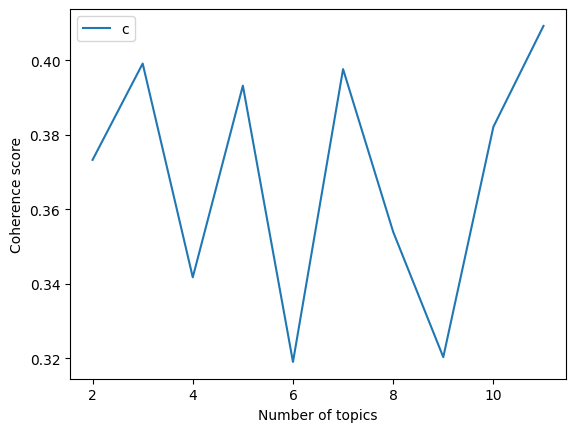

In [18]:
plt.plot(range(minTopics, maxTopics+1), coherenceValues)
plt.xlabel("Number of topics")
plt.ylabel("Coherence score")
plt.legend(("coherenceValues"), loc="best")
plt.show()
# model with 3 topics gives the most meaningful grouping of words

In [19]:
finalNumTopic = 3
lsaModelFinal = LsiModel(docTerm, num_topics=finalNumTopic, id2word = dictionary)
lsaModelFinal.print_topics(finalNumTopic, 5)

[(0,
  '0.615*"mr" + 0.429*"said" + 0.187*"trump" + 0.130*"state" + 0.119*"would"'),
 (1,
  '-0.537*"mr" + -0.319*"trump" + 0.286*"said" + 0.242*"saudi" + 0.142*"weight"'),
 (2,
  '-0.460*"saudi" + -0.264*"taliban" + 0.249*"weight" + -0.194*"afghanistan" + 0.191*"dr"')]